# CosmoFit Dataset Zoo: A Tour of Every Built-in Dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/dataset_zoo.ipynb)

CosmoFit bundles eight observational datasets. This notebook loads each
one on its own against a fixed fiducial cosmology (Planck-2018-like
flat LCDM, **not fit** to any of them) and plots it, so you can see
what each dataset actually looks like before deciding what to combine
in a real fit.

| Key | Dataset | Probe |
|---|---|---|
| `"cc"` | Cosmic Chronometers (Favale et al. 2023) | H(z), 32 points |
| `"desi"` | DESI 2024 BAO | D_M/r_d, D_H/r_d, D_V/r_d |
| `"sdss_bao"` | BOSS DR12 + eBOSS DR16 LRG/QSO | D_M/r_d, D_H/r_d |
| `"pantheon"` | Pantheon+SH0ES | SN Ia distance modulus, 1701 SNe |
| `"des_sn5yr"` | DES-SN5YR | SN Ia distance modulus, 1820 SNe |
| `"planck"` | Planck 2018 distance priors | R, l_A, omega_b h^2 |
| `"fsigma8"` | "Gold-2018" RSD compilation | growth rate f*sigma8(z), 22 points |
| `"s8"` | KiDS-1000 / DES Y3 weak lensing | S8 = sigma8*sqrt(Omega_m/0.3) |

It ends with a note on **which datasets not to combine** with each
other, and one example of a valid combined fit.

**Running this notebook:** open in Colab and *Runtime → Run all*
(no MCMC in this one -- well under a minute).


## Setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e .

    # The editable install above runs in a subprocess, so the .pth /
    # editable-finder file it writes isn't picked up by *this*
    # already-running kernel without a restart. Without this, `import
    # CosmoFit` can resolve to the bare repo checkout directory
    # instead (same name as the package, and `/content` is on
    # sys.path in Colab) -- an empty namespace package with none of
    # LCDM/CPL/Fitter defined, raising a confusing "unknown location"
    # ImportError. Pointing sys.path at src/ directly sidesteps that.
    import importlib
    sys.path.insert(0, os.path.abspath("src"))
    importlib.invalidate_caches()
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e . from the repository root).")


Not running in Colab -- assuming CosmoFit is already installed (pip install -e . from the repository root).


In [2]:
import matplotlib.pyplot as plt

from CosmoFit import LCDM, Fitter, available_datasets

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

FIDUCIAL = {"H0": 67.4, "Omega_m": 0.315, "rd": 147.1, "Omega_b": 0.0493}

available_datasets()

{'cc': ['favale2023'],
 'desi': ['desi2024'],
 'sdss_bao': ['dr12+dr16'],
 'pantheon': ['pantheon+sh0es'],
 'des_sn5yr': ['des-sn5yr'],
 'fsigma8': ['gold2018'],
 's8': ['kids1000', 'des_y3'],
 'planck': ['planck2018']}

A small helper: build a single-dataset `Fitter` at the fixed
fiducial point above (no fitting), print its chi2, and return it so
we can call `fit.plots....()` on it.

In [3]:
def quick_look(dataset_key, free_params=("H0", "Omega_m")):
    fit = Fitter(
        model=LCDM,
        datasets=[dataset_key],
        free_params=list(free_params),
        initial=FIDUCIAL,
    )
    chi2 = fit.chi2()
    print(f"{dataset_key:>10s}: n_data={fit.n_data:5d}   "
          f"chi2={chi2:8.2f}   chi2/dof~{chi2/fit.n_data:.2f}")
    return fit

## Cosmic Chronometers (`"cc"`)

        cc: n_data=   32   chi2=   13.34   chi2/dof~0.42


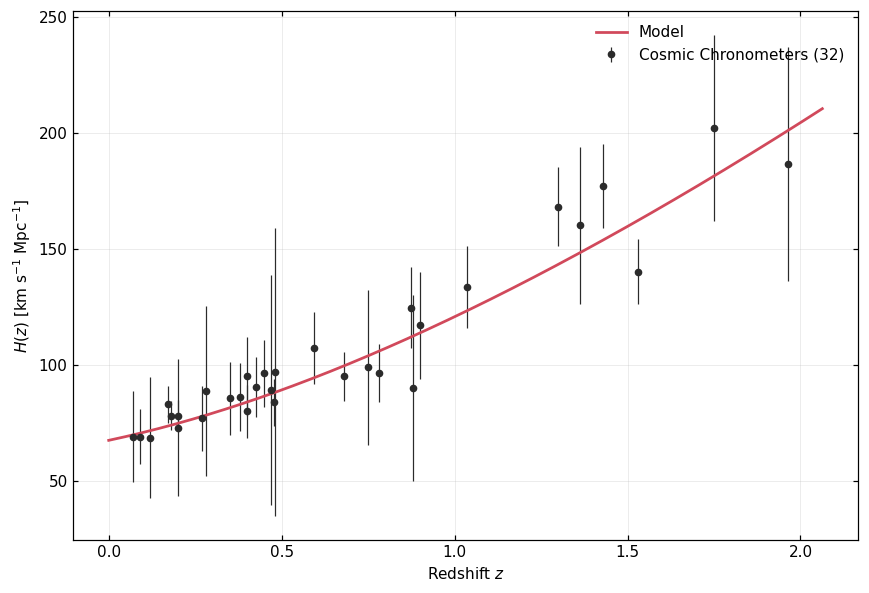

In [4]:
fit_cc = quick_look("cc")
fig = fit_cc.plots.hz()

## DESI 2024 BAO (`"desi"`)

      desi: n_data=   12   chi2=   20.71   chi2/dof~1.73


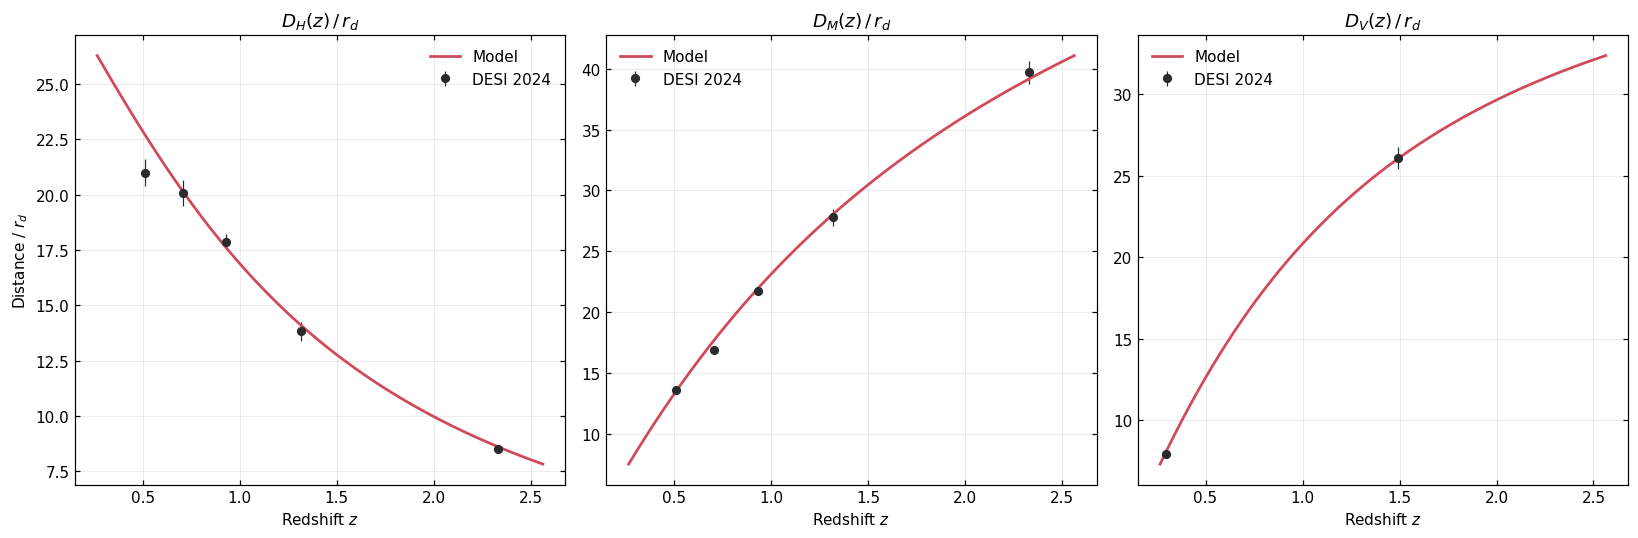

In [5]:
fit_desi = quick_look("desi")
fig = fit_desi.plots.bao_distances()

## SDSS BAO -- BOSS DR12 + eBOSS DR16 LRG/QSO (`"sdss_bao"`)

  sdss_bao: n_data=    8   chi2=    6.58   chi2/dof~0.82


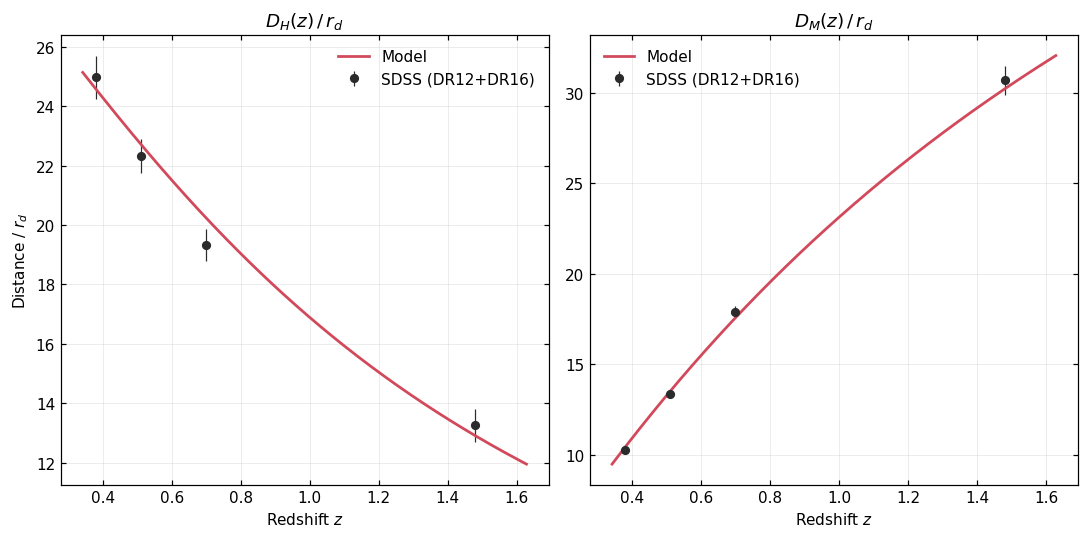

In [6]:
fit_sdss = quick_look("sdss_bao")
fig = fit_sdss.plots.sdss_bao_distances()

## Pantheon+SH0ES (`"pantheon"`)

  pantheon: n_data= 1624   chi2= 1457.50   chi2/dof~0.90


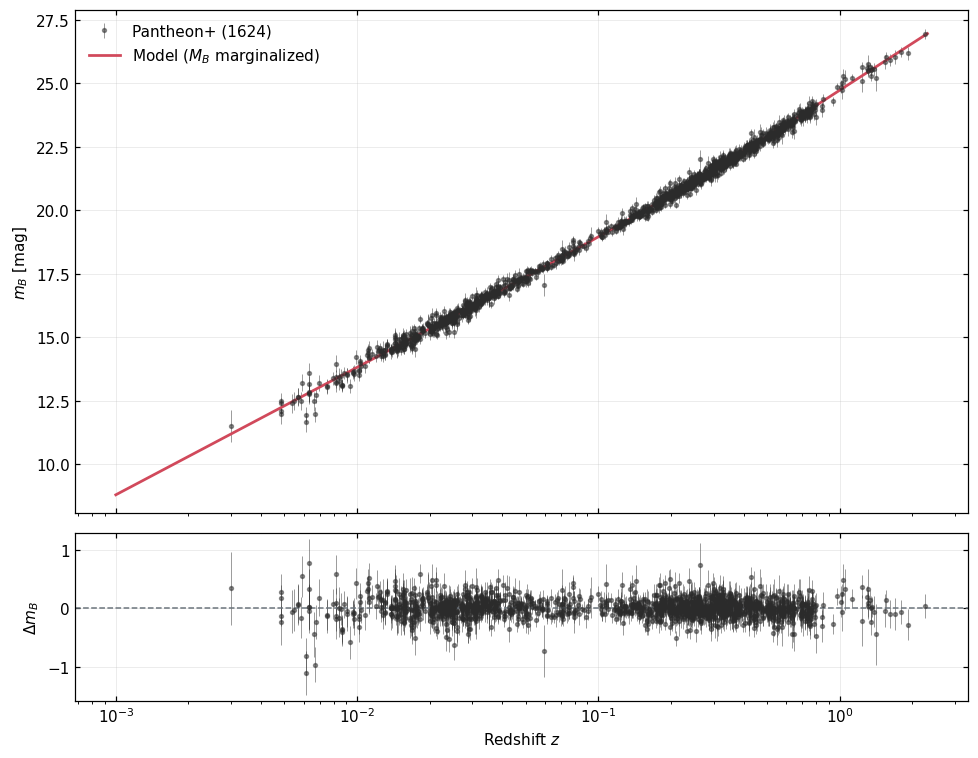

In [7]:
fit_pantheon = quick_look("pantheon")
fig = fit_pantheon.plots.hubble_diagram()

## DES-SN5YR (`"des_sn5yr"`)

 des_sn5yr: n_data= 1820   chi2= 1632.45   chi2/dof~0.90


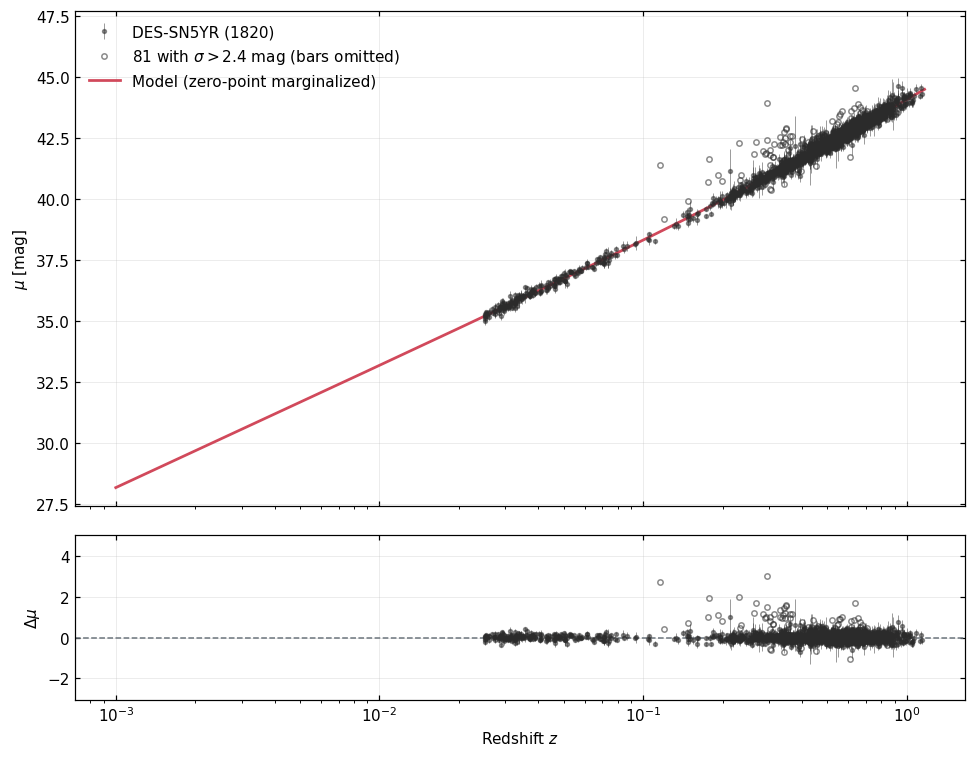

In [8]:
fit_des = quick_look("des_sn5yr")
fig = fit_des.plots.des_hubble_diagram()

## Planck 2018 distance priors (`"planck"`)

    planck: n_data=    3   chi2=    0.71   chi2/dof~0.24


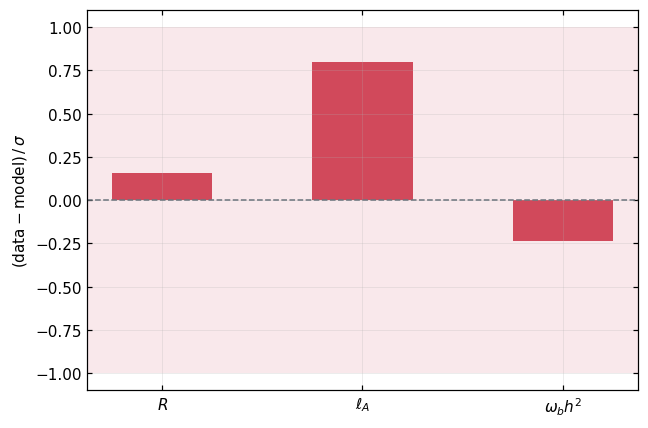

In [9]:
fit_planck = quick_look("planck", free_params=["H0", "Omega_m"])
fig = fit_planck.plots.planck_residuals()

## Growth rate -- "Gold-2018" RSD compilation (`"fsigma8"`)

Unlike the datasets above (all background/expansion-history probes), this one measures the growth *rate* of structure -- f(z)*sigma8(z) -- and is what makes `f_R0`/`n` (FRHuSawicki f(R)'s parameters) actually constrainable; see [`modified_gravity_growth.ipynb`](modified_gravity_growth.ipynb).

   fsigma8: n_data=   22   chi2=   17.44   chi2/dof~0.79


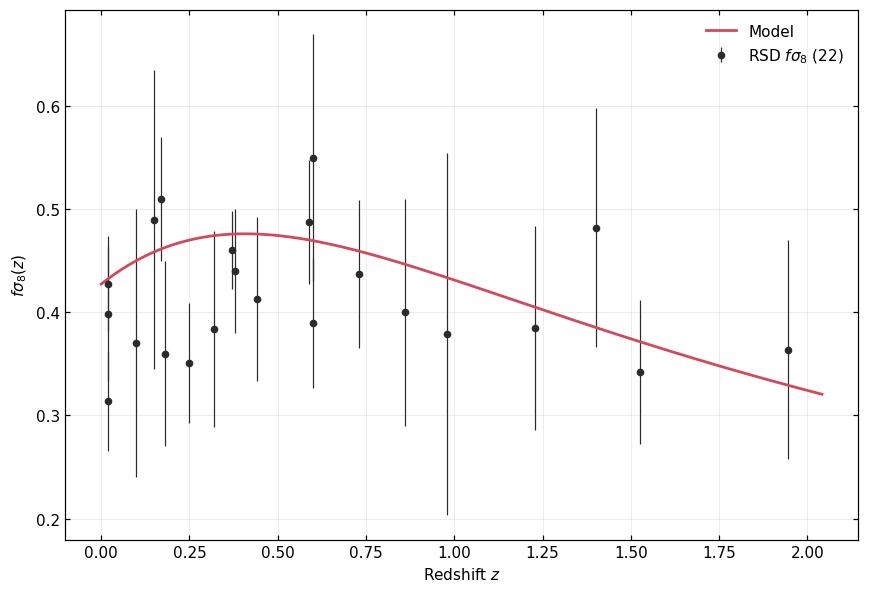

In [10]:
fit_fs8 = quick_look("fsigma8", free_params=["H0", "Omega_m", "sigma8"])
fig = fit_fs8.plots.growth()


## S8 weak-lensing prior (`"s8"`)

A single Gaussian constraint on S8 = sigma8*sqrt(Omega_m/0.3), not a per-redshift curve like the others -- `quick_look` doesn't apply (there's no `fitter.plots` figure for one number), so this is a direct likelihood call instead.

In [11]:
from CosmoFit import LCDM
from CosmoFit.likelihoods.s8 import S8Likelihood
from CosmoFit.cosmology.core.parameters import CosmologyParameters

fiducial_cosmo = LCDM(CosmologyParameters(H0=67.4, Omega_m=0.315, sigma8=0.811))
lk_s8 = S8Likelihood(fiducial_cosmo)  # default version="kids1000"

print(f"model S8 = {lk_s8.model():.3f}")
print(f"KiDS-1000 S8_obs = {lk_s8.data.value:.3f} +/- {lk_s8.data.sigma:.3f}   "
      f"chi2 = {lk_s8.chi2():.2f}")


model S8 = 0.831
KiDS-1000 S8_obs = 0.759 +/- 0.022   chi2 = 10.25


## Datasets you should *not* combine

Putting more datasets into `Fitter(datasets=[...])` isn't always
better -- some pairs are built from overlapping data and would
double-count it, artificially tightening (and biasing) the posterior:

- **`"pantheon"` + `"des_sn5yr"`**: DES-SN5YR's low-redshift "anchor"
  sample (~11% of it, the CfA3/CfA4/Foundation surveys) is also
  compiled into Pantheon+.
- **`"desi"` + `"sdss_bao"`**: DESI targets much of the same sky BOSS
  and eBOSS did.

Pick *one* supernova compilation and *one* BAO compilation per fit.
Everything else (`"cc"`, `"planck"`) is independent of all of the
above and safe to add freely.

## A valid combined fit

Cosmic Chronometers + SDSS BAO + DES-SN5YR + Planck -- four mutually
independent probes (a different combination than
[`cpl_mcmc_analysis.ipynb`](cpl_mcmc_analysis.ipynb)'s CC+DESI+Pantheon+Planck,
to show these aren't the only "correct" choice). Best-fit only here
(no MCMC) -- see the other notebooks for full posteriors.

In [12]:
fit = Fitter(
    model=LCDM,
    datasets=["cc", "sdss_bao", "des_sn5yr", "planck"],
    free_params=["H0", "Omega_m"],
    initial=FIDUCIAL,
)

print("chi2 breakdown at the fiducial point:")
for name, chi2 in fit.chi2_breakdown().items():
    print(f"  {name:>12s}: {chi2:8.2f}")

fit.best_fit()
print(f"\nbest fit: {fit.best_fit_params}")
print(f"chi2_min = {fit.best_fit_chi2:.2f}  ({fit.n_data} data points)")

chi2 breakdown at the fiducial point:
            CC:    13.34
      SDSS-BAO:     6.58
     DES-SN5YR:  1632.45
        Planck:     0.71

best fit: {'H0': np.float64(67.39508698032336), 'Omega_m': np.float64(0.3146462986809778)}
chi2_min = 1652.56  (1863 data points)


## Next steps

- [`quickstart.ipynb`](quickstart.ipynb) -- the shortest path to a
  real MCMC fit.
- [`model_zoo_comparison.ipynb`](model_zoo_comparison.ipynb) -- all
  six cosmological models fit to the same data and compared.
- [`cpl_mcmc_analysis.ipynb`](cpl_mcmc_analysis.ipynb) -- a full,
  single-model analysis with convergence diagnostics and every figure
  `fit.plots` can produce.
- [`modified_gravity_growth.ipynb`](modified_gravity_growth.ipynb) --
  f(Q)/f(R,T)/f(R) modified gravity and growth of structure, using
  `"fsigma8"`/`"s8"` for real.
